In [70]:
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, factorize_psd_truncated, create_4q_gst_config, is_isometry, run_simple_gds_on_gates_jax
from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
 
from mGST.low_level_jit import cost_function_jax_mps, gradient_all_3_and_value_jit, cost_function_numba, cost_function_jax

import jax.numpy as jnp
import jax

import numpy as np

import matplotlib.pyplot as plt

backend = "iqmfakeapollo"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
Q4_GST = create_4q_gst_config()

K, X, E, rho, y, J, l, depth, pdim, dim_squared, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend, seed=42
)

2025-02-20 11:48:13,180 - iqm.benchmarks.logging_config - INFO - Now generating 2000 random GST circuits...
2025-02-20 11:48:15,292 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2025-02-20 11:48:15,292 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-02-20 11:48:26,350 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1, 3, 4]
2025-02-20 11:48:26,370 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-02-20 11:48:26,393 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
INFO:2025-02-20 11:49:30,891:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-02-20 11:49:30,891 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': m

In [4]:
K_np = np.array(K)
E_np = np.array(E)
rho_np = np.array(rho)
y_np = np.array(y)

# creating the parameters needed for the jax version
num_povm = E.shape[0]
dim = int(jnp.sqrt(E.shape[1]))

povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state = jnp.reshape(rho, shape=(dim, dim))

indices_list = [indices[indices != -1] for indices in J]

kraus_tensor = K
prob_matrix = y

state_psd = factorize_psd_truncated(psd=state, max_rank=1)
povm_psd  = factorize_psd_truncated(psd=povm_tensor, max_rank=1)

jnp.allclose(state_psd @ state_psd.T, state), jnp.allclose(povm_psd @ povm_psd.conj().transpose(0, 2, 1), povm_tensor)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [25]:
initial_cost = cost_function_jax_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, jit=True)
initial_cost

Initial count: 15


Array(0.00062581, dtype=float64)

In [10]:
%timeit cost_function_jax_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, jit=True)

Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 242 the new count changed to: 5
at iteration 393 the new count changed to: 6
at iteration 544 the new count changed to: 7
at iteration 696 the new count changed to: 8
at iteration 848 the new count changed to: 9
at iteration 1000 the new count changed to: 10
at iteration 1166 the new count changed to: 11
at iteration 1332 the new count changed to: 12
at iteration 1499 the new count changed to: 13
at iteration 1666 the new count changed to: 14
at iteration 1833 the new count changed to: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
139 ms ± 3.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
%timeit gradient_k_and_value_jit(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
9.31 s ± 222 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [15]:
%timeit gradient_all_3_and_value_jit(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
10.2 s ± 248 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [18]:
10.2 * 100 /60

16.999999999999996

In [19]:
state_psd.shape, povm_psd.shape

((16, 1), (16, 16, 1))

In [21]:
povm_matrix = jnp.transpose(povm_psd, (0, 2, 1)).reshape((num_povm * 1, dim))
is_isometry(povm_matrix)

Array(True, dtype=bool)

In [22]:
jnp.array([state_psd]).shape

(1, 16, 1)

In [26]:
# try the optimization using the update functions
kraus_opt_test_geodesic, cost_fn_history_test_geodesic = run_simple_gds_on_gates_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=10, target_rel_prec=1e-3, step_size=50, optimize_step=False, use_geodesic=True)

iteration:  0
Initial count: 15
cost:  0.0006258096017386882
iteration:  1
Initial count: 15
cost:  0.0005570235375896271
iteration:  2
Initial count: 15
cost:  0.0005218107679886996
iteration:  3
Initial count: 15
cost:  0.0004995521696915633
iteration:  4
Initial count: 15
cost:  0.000483893714599985
iteration:  5
Initial count: 15
cost:  0.00047221126572836704
iteration:  6
Initial count: 15
cost:  0.0004631403586667719
iteration:  7
Initial count: 15
cost:  0.0004558723352696219
iteration:  8
Initial count: 15
cost:  0.0004498929626533011
iteration:  9
Initial count: 15
cost:  0.0004448604351059445


In [33]:
povm_psd.shape

(16, 16, 1)

In [34]:
# try the optimization using the update functions
kraus_opt, povm_opt, sate_opt, cost_fn_history_all_opt = run_simple_gds_on_gates_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=10, target_rel_prec=1e-3, step_size=50, optimize_step=False, use_geodesic=True)

iteration:  0
Initial count: 15
cost:  0.0006258096017386882
iteration:  1
Initial count: 15
cost:  0.0005511199496883764
iteration:  2
Initial count: 15
cost:  0.0005168035552703937
iteration:  3
Initial count: 15
cost:  0.0004939840837651837
iteration:  4
Initial count: 15
cost:  0.0004777105352154946
iteration:  5
Initial count: 15
cost:  0.0004654745683528412
iteration:  6
Initial count: 15
cost:  0.0004558426451289006
iteration:  7
Initial count: 15
cost:  0.0004479469187826356
iteration:  8
Initial count: 15
cost:  0.0004412362536530275
iteration:  9
Initial count: 15
cost:  0.0004353474921169347


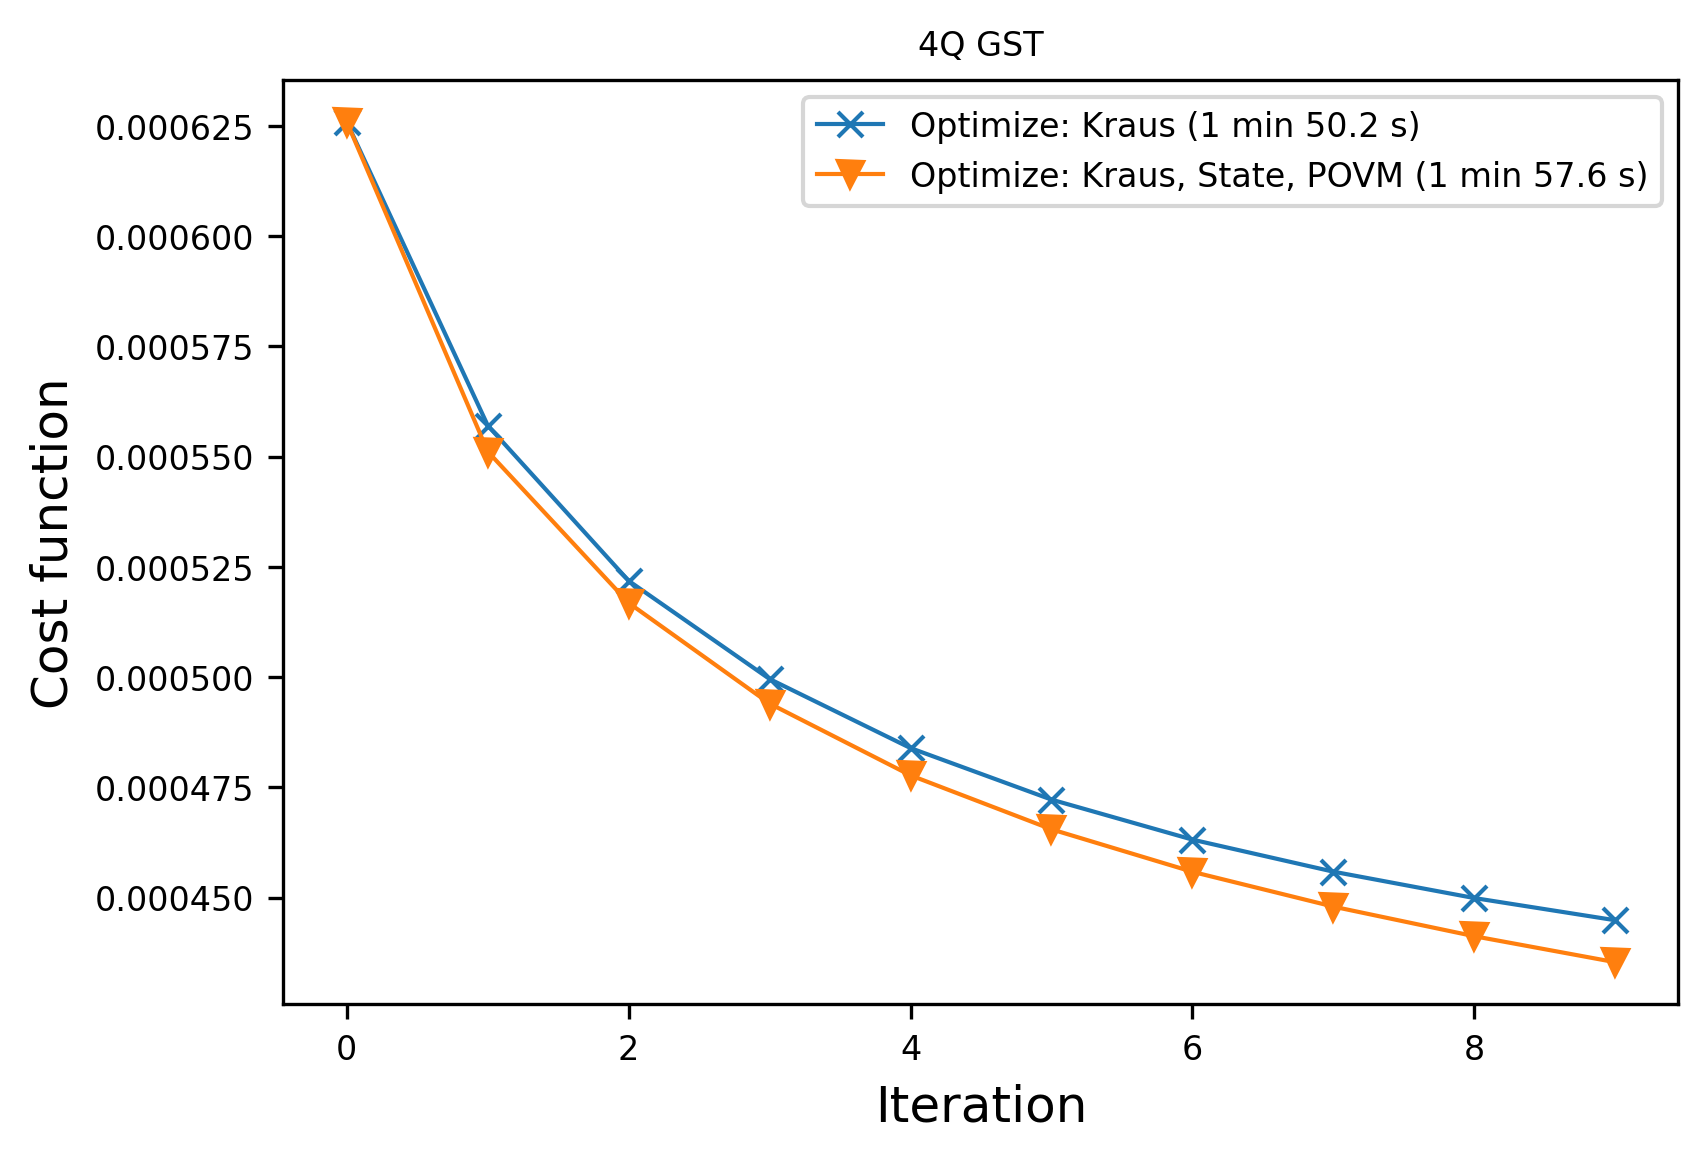

In [36]:
plt.figure(figsize=(6, 4), dpi=300)
plt.plot(range(len(cost_fn_history_test_geodesic)), cost_fn_history_test_geodesic, marker="x", linestyle="-", linewidth=1, markersize=6, label="Optimize: Kraus (1 min 50.2 s)")
plt.plot(range(len(cost_fn_history_all_opt)), cost_fn_history_all_opt, marker="v", linestyle="-", linewidth=1, markersize=6, label="Optimize: Kraus, State, POVM (1 min 57.6 s)")
plt.xlabel("Iteration", fontsize=12)
plt.title(r"4Q GST")
plt.ylabel("Cost function", fontsize=12)
plt.legend()

# Compare against previously implemented methods in mGST for 2Q GST

In [38]:
from mGST.algorithm import run_mGST

In [37]:
# first let's calculate the cost function using numba
# Euclidean Gradient
Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=4,
)

K, X, E, rho, y, J, l, d, pdim, r, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend
)

2025-02-20 17:45:10,730 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2025-02-20 17:45:11,325 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2025-02-20 17:45:11,326 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-02-20 17:45:15,703 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2025-02-20 17:45:15,709 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-02-20 17:45:15,742 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [50]:
E.shape, rho.shape, K.shape

((4, 16), (16,), (5, 4, 4, 4))

In [46]:
K_np = np.array(K)
E_np = np.array(E)
rho_np = np.array(rho)
y_np = np.array(y)

In [73]:
# creating the parameters needed for the jax version
num_povm = E.shape[0]
dim = int(jnp.sqrt(E.shape[1]))

povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state = jnp.reshape(rho, shape=(dim, dim))

indices_list = [indices[indices != -1] for indices in J]

kraus_tensor = K
prob_matrix = y

state_psd = factorize_psd_truncated(psd=state, max_rank=1)
povm_psd  = factorize_psd_truncated(psd=povm_tensor, max_rank=1)

jnp.allclose(state_psd @ state_psd.T, state), jnp.allclose(povm_psd @ povm_psd.conj().transpose(0, 2, 1), povm_tensor)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [68]:
cost_function_numba(K_np, E_np, rho_np, J, y_np), 

0.0018090037849567797

In [74]:
cost_function_jax(X, E, rho, indices_list, y)

Array(0.001809, dtype=float64)

In [75]:
kraus_updated_2q_mgst, x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, cost_fn_history_2q_mgst = run_mGST(
    y_np, indices_list, 0, d, r, rK, n_povm, bsize, meas_samples,
    init = [K_np, E_np, rho_np],
    method = "GD",
    max_iter=100,
    target_rel_prec=1e-4,
)

Starting mGST optimization...
100%|██████████| 70/70 [10:50<00:00,  9.29s/it]
	 Convergence criterion satisfied
	 Final objective 0.00015345610453170925 in time 650.66s


In [78]:
# jax version to compile first
cost_value_jax_2q_init = cost_function_jax_mps(kraus_tensor, povm_tensor, state_psd, indices_list, prob_matrix, jit=True)
cost_value_jax_2q_init

Initial count: 30


Array(0.001809, dtype=float64)

In [79]:
kraus_updated_2q_jax, povm_updated_2q_jax, state_updated_2q_jax, cost_fn_history_2q_jax = run_simple_gds_on_gates_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-3, step_size=1e-8, optimize_step=True, use_geodesic=False)

iteration:  0
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
optimized step size:  [4.56103517]
cost:  0.0018090037849567786
iteration:  1
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
optimized step size:  [5.27343751]
cost:  0.0012822566212795522
iteration:  2
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
In

In [84]:
kraus_updated_2q_opt_step_all, povm_updated_2q_opt_step_all, state_updated_2q_opt_step_all, cost_fn_history_2q_opt_step_all = run_simple_gds_on_gates_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-3, step_size=1e-8, optimize_step=True, use_geodesic=False)

iteration:  0
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
optimized step size:  [3.99121095]
cost:  0.0018090037849567786
iteration:  1
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
optimized step size:  [6.20019532]
cost:  0.001271191118216871
iteration:  2
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Ini

In [86]:
len(cost_fn_history_2q_opt_step_all)

173

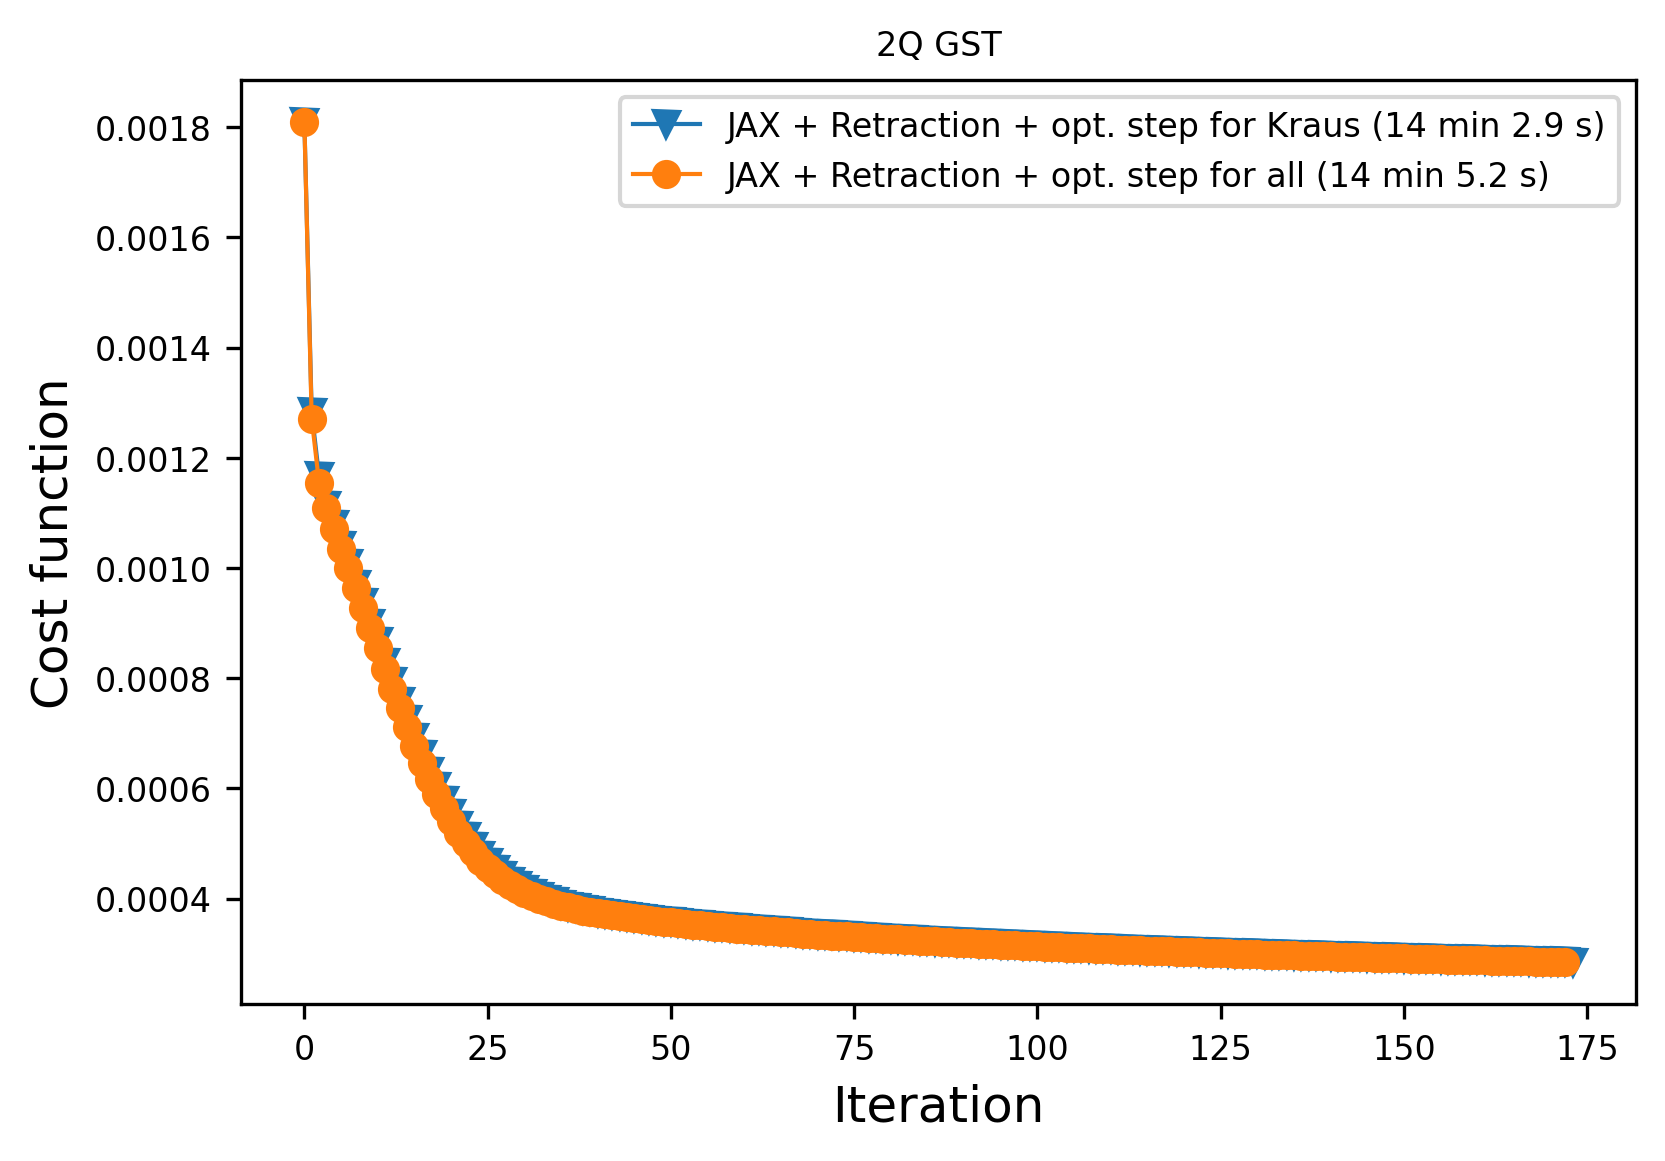

In [88]:
plt.figure(figsize=(6, 4), dpi=300)
# plt.plot(range(len(cost_fn_history_2q_mgst)), cost_fn_history_2q_mgst, marker="x", linestyle="-", linewidth=1, markersize=6, label="mGST (10 min 50.7 s)")
plt.plot(range(len(cost_fn_history_2q_jax)), cost_fn_history_2q_jax, marker="v", linestyle="-", linewidth=1, markersize=6, label="JAX + Retraction + opt. step for Kraus (14 min 2.9 s)")
plt.plot(range(len(cost_fn_history_2q_opt_step_all)), cost_fn_history_2q_opt_step_all, marker="o", linestyle="-", linewidth=1, markersize=6, label="JAX + Retraction + opt. step for all (14 min 5.2 s)")
plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q GST")
plt.ylabel("Cost function", fontsize=12)
plt.legend()

In [106]:
povm_psd.shape

(4, 4, 1)

In [97]:
test_rank = 3
test_povm = factorize_psd_truncated(psd=povm_tensor, max_rank=test_rank)
test_matrix = jnp.reshape(test_povm, (num_povm*test_rank, dim))
is_isometry(test_matrix), jnp.allclose(test_povm @ test_povm.conj().transpose(0, 2, 1), povm_tensor)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [105]:
test_matrix_2 = jnp.reshape(test_povm.transpose((0, 2, 1)), (num_povm*test_rank, dim))
jnp.allclose(test_matrix, test_matrix_2), is_isometry(test_matrix_2)

(Array(False, dtype=bool), Array(True, dtype=bool))

In [108]:
# checking that the code reverses what the other one does
from mGST.utility_functions_comparisons import euclidean_gradients_to_stiefel

In [111]:
# POVM tensor to stiefel
previous_shape = povm_psd.shape[0], povm_psd.shape[2], povm_psd.shape[1]
_, povm_isometry =  euclidean_gradients_to_stiefel(gradient_tensor=povm_psd, operator_tensor=povm_psd, operator_name="povm")

new_povm_psd = jnp.reshape(povm_isometry, shape=previous_shape)
new_povm_psd = jnp.transpose(new_povm_psd, axes=(0, 2, 1))

jnp.allclose(new_povm_psd, povm_psd), povm_psd.shape, new_povm_psd.shape

(Array(True, dtype=bool), (4, 4, 1), (4, 4, 1))

In [112]:
kraus_updated_2q_opt_step_all_v2, povm_updated_2q_opt_step_all_v2, state_updated_2q_opt_step_all_v2, cost_fn_history_2q_opt_step_all_v2 = run_simple_gds_on_gates_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-3, step_size=1e-8, optimize_step=True, use_geodesic=False)

iteration:  0
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
optimized step size:  [3.99121095]
cost:  0.0018090037849567786
iteration:  1
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
optimized step size:  [6.20019532]
cost:  0.001271191118216871
iteration:  2
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Ini

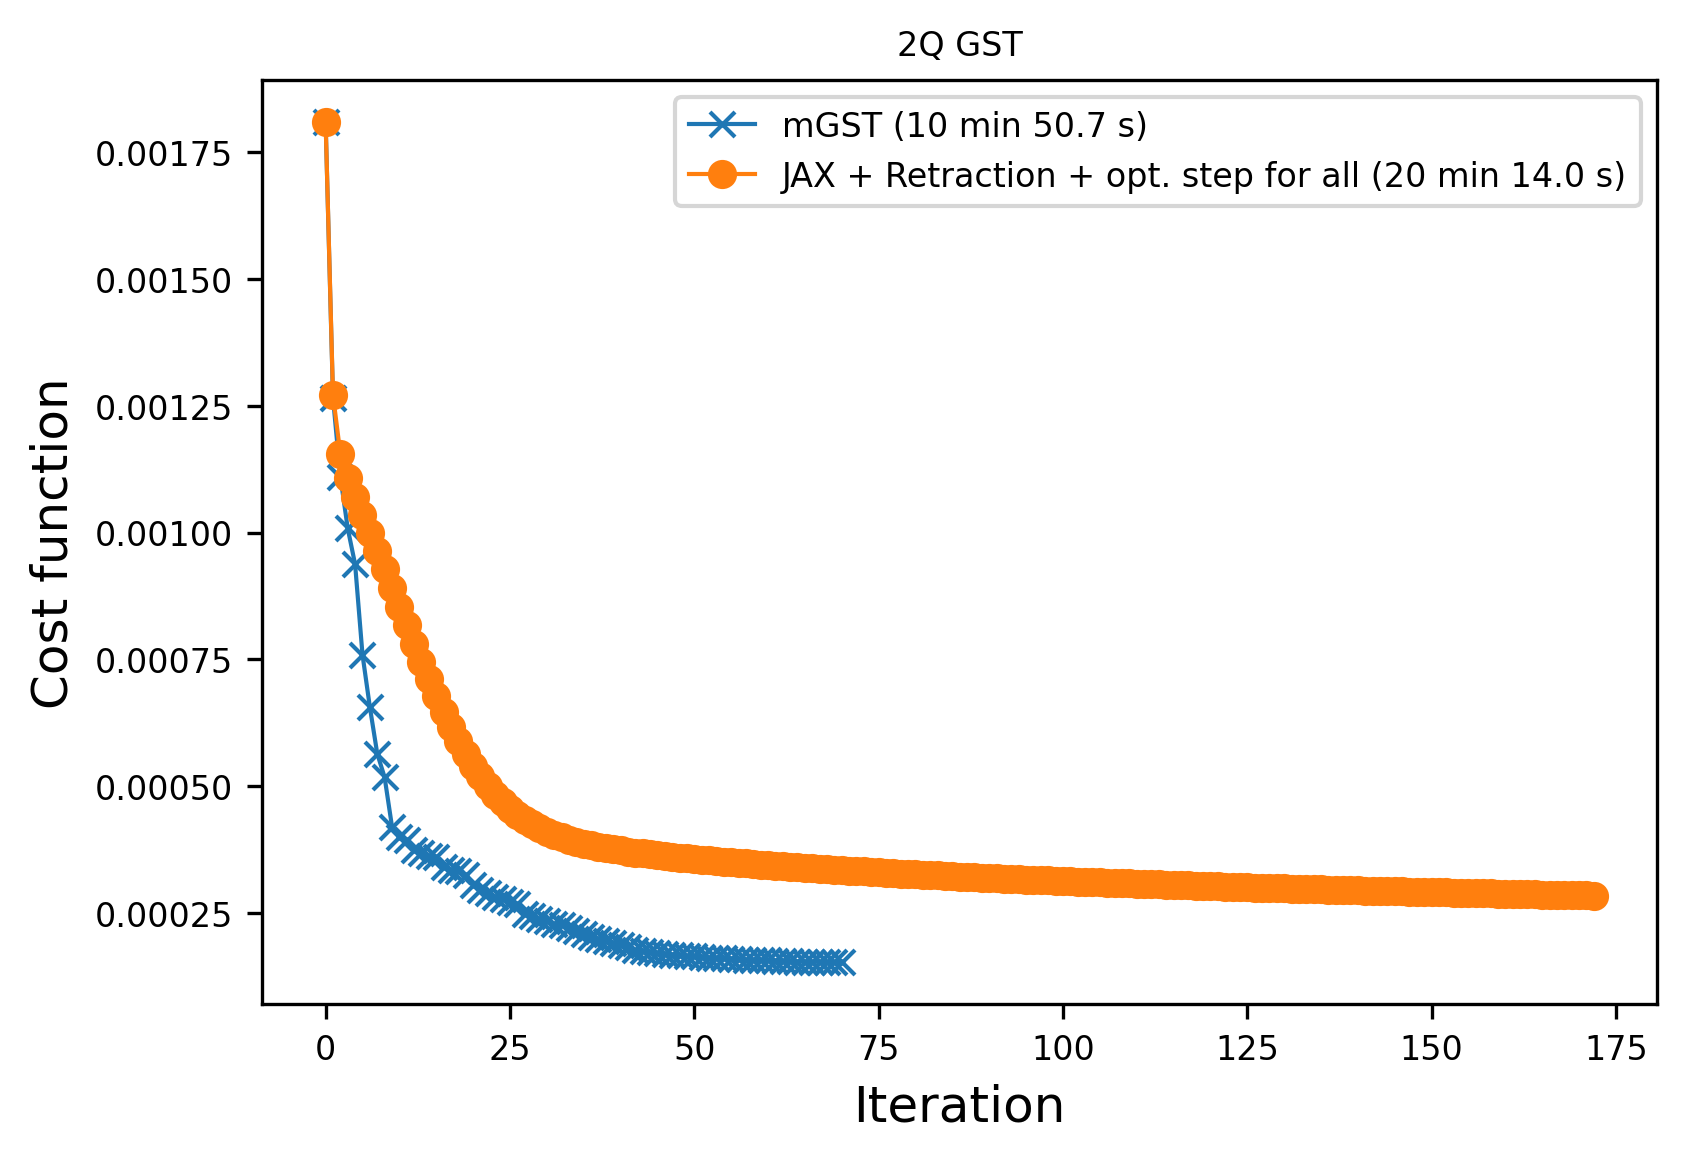

In [113]:
plt.figure(figsize=(6, 4), dpi=300)
plt.plot(range(len(cost_fn_history_2q_mgst)), cost_fn_history_2q_mgst, marker="x", linestyle="-", linewidth=1, markersize=6, label="mGST (10 min 50.7 s)")
plt.plot(range(len(cost_fn_history_2q_opt_step_all_v2)), cost_fn_history_2q_opt_step_all_v2, marker="o", linestyle="-", linewidth=1, markersize=6, label="JAX + Retraction + opt. step for all (20 min 14.0 s)")
plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q GST")
plt.ylabel("Cost function", fontsize=12)
plt.legend()